# Exploring and cleaning the merged dataset

This file explores the new merged dataset with the features obtained from the feature engineering.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

## Initial information

We begin by importing the dataset and exploring its shape and columns.

In [12]:
df = pd.read_csv("../../clustering_dataset/merged_dataset.csv")
df = df.copy()

print(f"Merged dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Merged dataset sample:\n", df.head())
print(f"Merged dataset columns: {df.columns.tolist()}")

Merged dataset shape: 9637 rows x 14 columns
Merged dataset sample:
    avg_token_per_clause  duration_ms  popularity  swear_ratio  \
0              8.133929     207761.0          46     0.020856   
1             12.500000     207761.0          46     0.031111   
2              8.422222     193544.0          39     0.036939   
3              6.701754     169000.0          47     0.028796   
4              8.411765     194779.0          41     0.002331   

   syntactic_complexity  flow_complexity  percussiveness  harmonic_richness  \
0           2185.667694        12.949597      749.867573       10685.779648   
1           1875.149389        16.312098      923.558260       17961.470393   
2           1720.151111        11.905768      718.697137       14462.555735   
3            821.328082        16.001670      353.256499        5273.616923   
4            827.027951         9.729363      436.723786        8243.404892   

   trap_index  boombap_index  cloud_rap_index   drill_index  care

## Data distribution

Printing the data distribution for each feature.

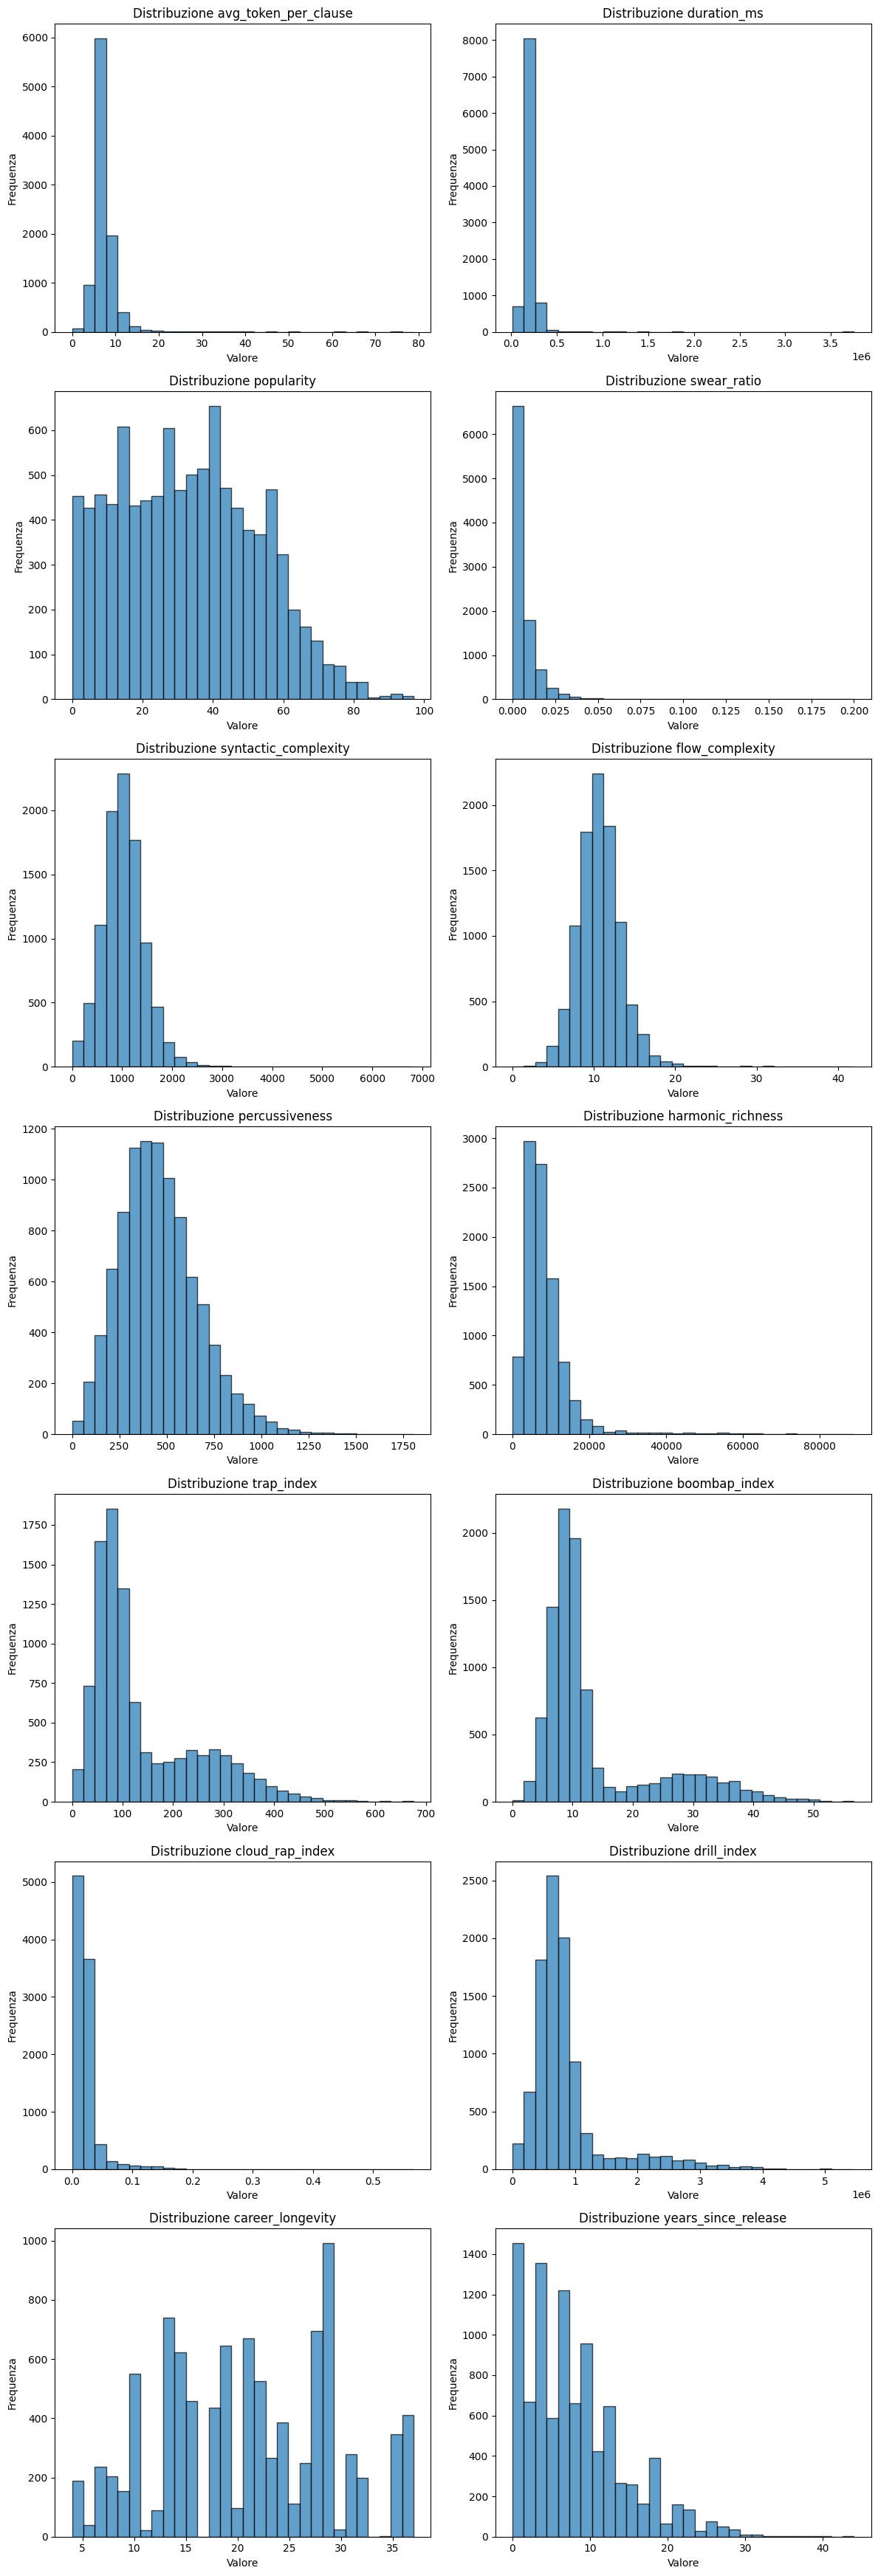

In [13]:
def data_distribution(df):
    num_cols = len(df.columns)
    cols = df.columns

    # Grid size: square-ish layout
    n_rows = math.ceil(num_cols / 2)
    n_cols = 2 if num_cols > 1 else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))

    # Flatten axes array even if there's only 1 plot
    axes = axes.flatten() if num_cols > 1 else [axes]

    for ax, col in zip(axes, cols):
        ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(f'Distribuzione {col}')
        ax.set_xlabel('Valore')
        ax.set_ylabel('Frequenza')

    # Hide unused subplots if any
    for ax in axes[num_cols:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
    return

data_distribution(df)

## Boxplot

Printing the boxplot for each feature in the dataset.

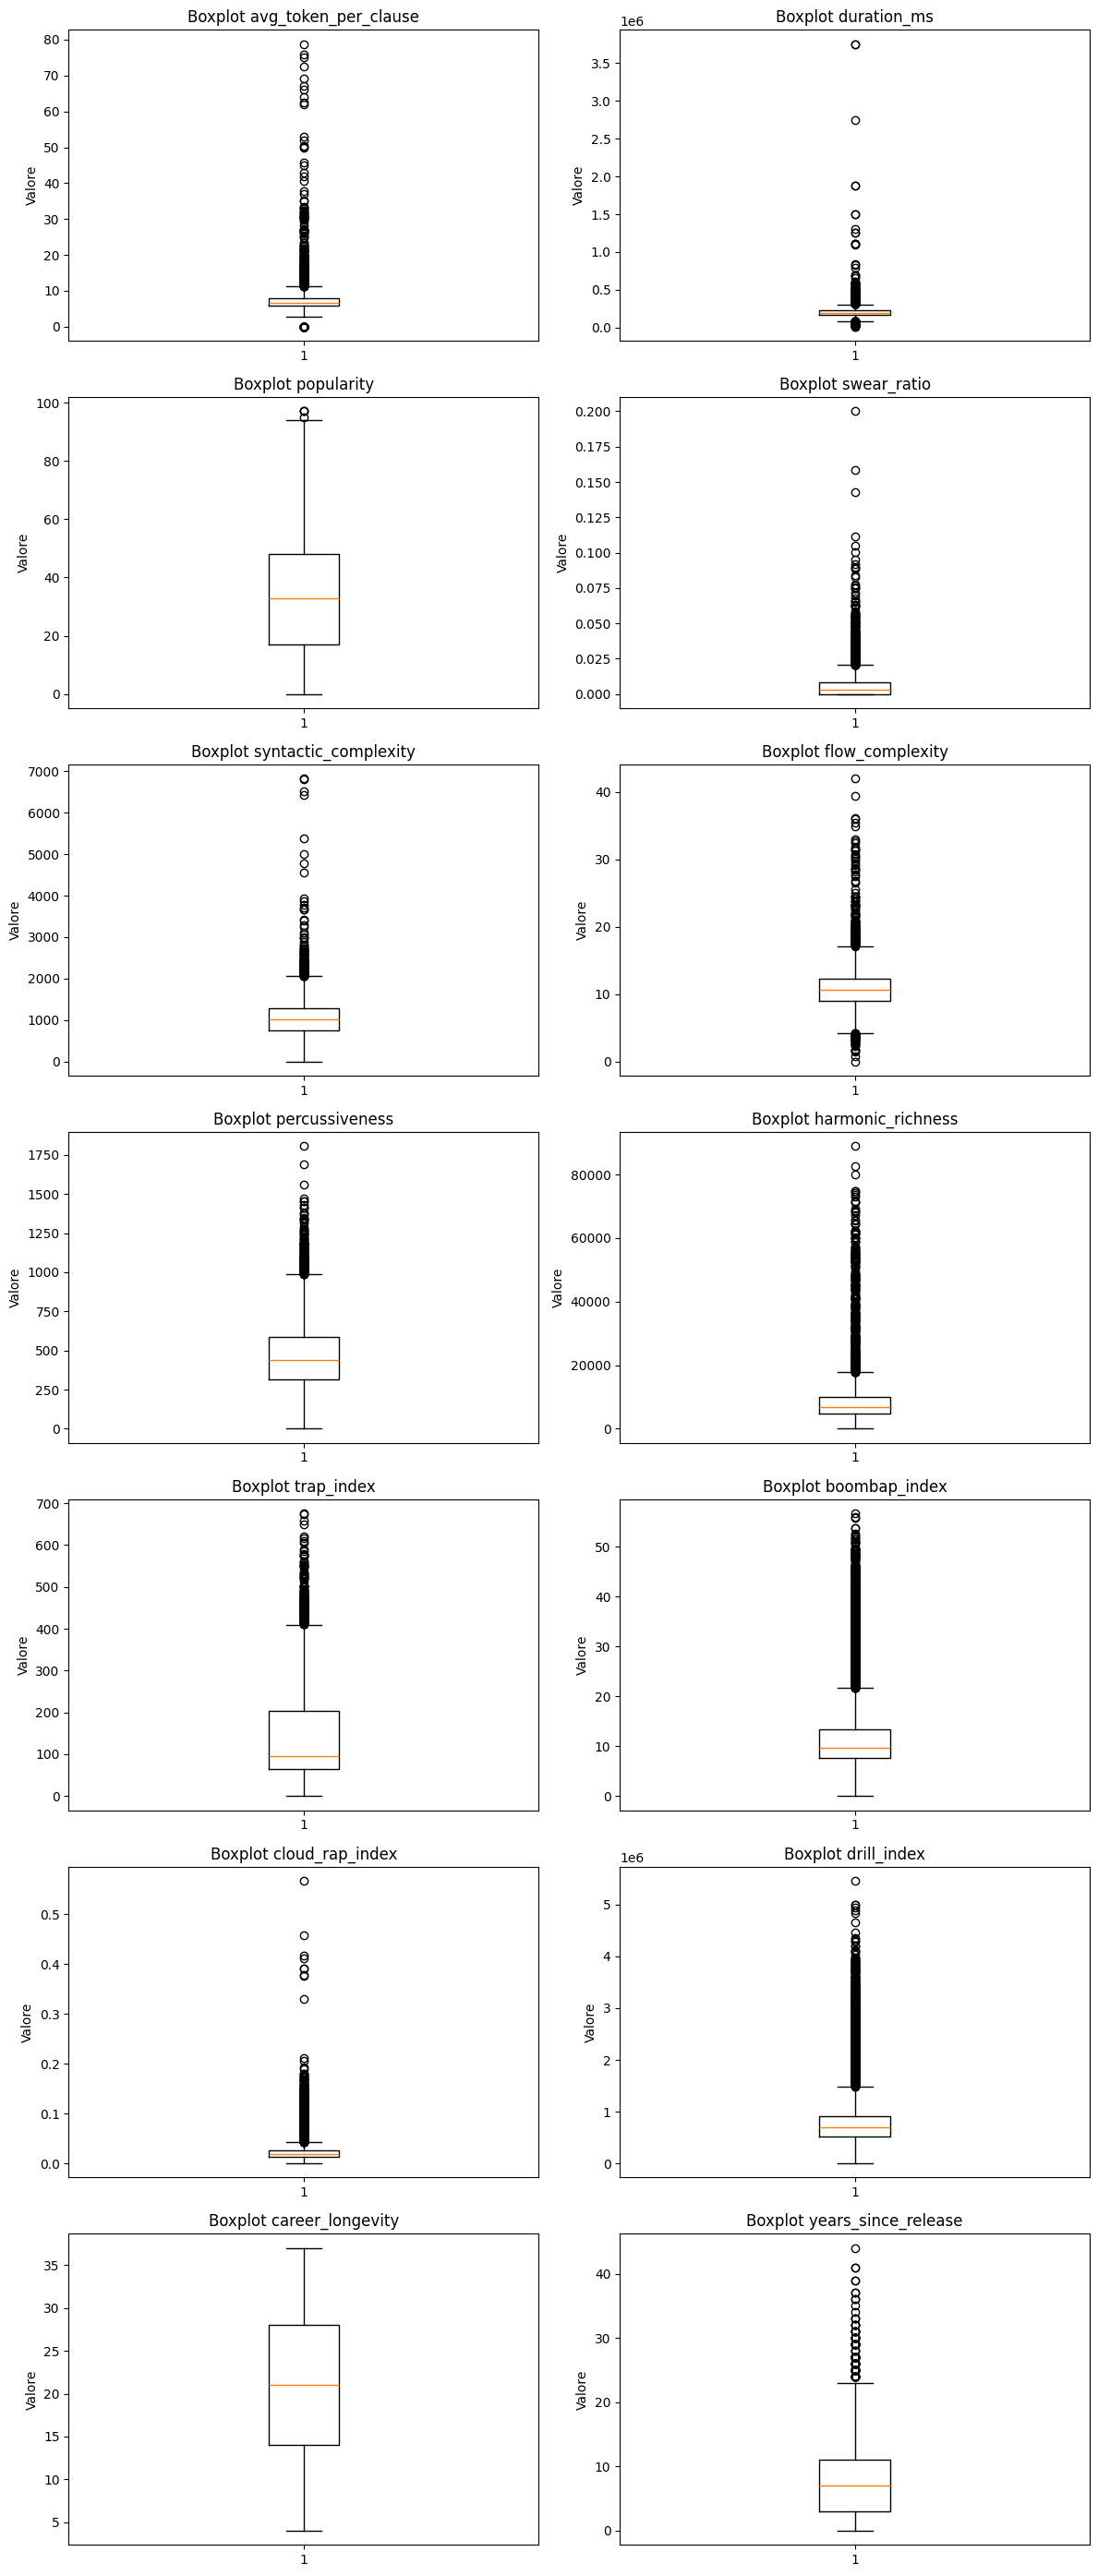

In [14]:
def boxplots(df):
    num_cols = len(df.columns)
    cols = df.columns

    # Grid size: square-ish layout
    n_rows = math.ceil(num_cols / 2)
    n_cols = 2 if num_cols > 1 else 1
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))

    # Flatten axes array to simplify iteration
    axes = axes.flatten() if num_cols > 1 else [axes]

    for ax, col in zip(axes, cols):
        ax.boxplot(df[col].dropna(), vert=True)
        ax.set_title(f'Boxplot {col}')
        ax.set_ylabel('Valore')

    # Hide unused axes (if grid > num columns)
    for ax in axes[num_cols:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
    return

boxplots(df)

## Correlation heatmap

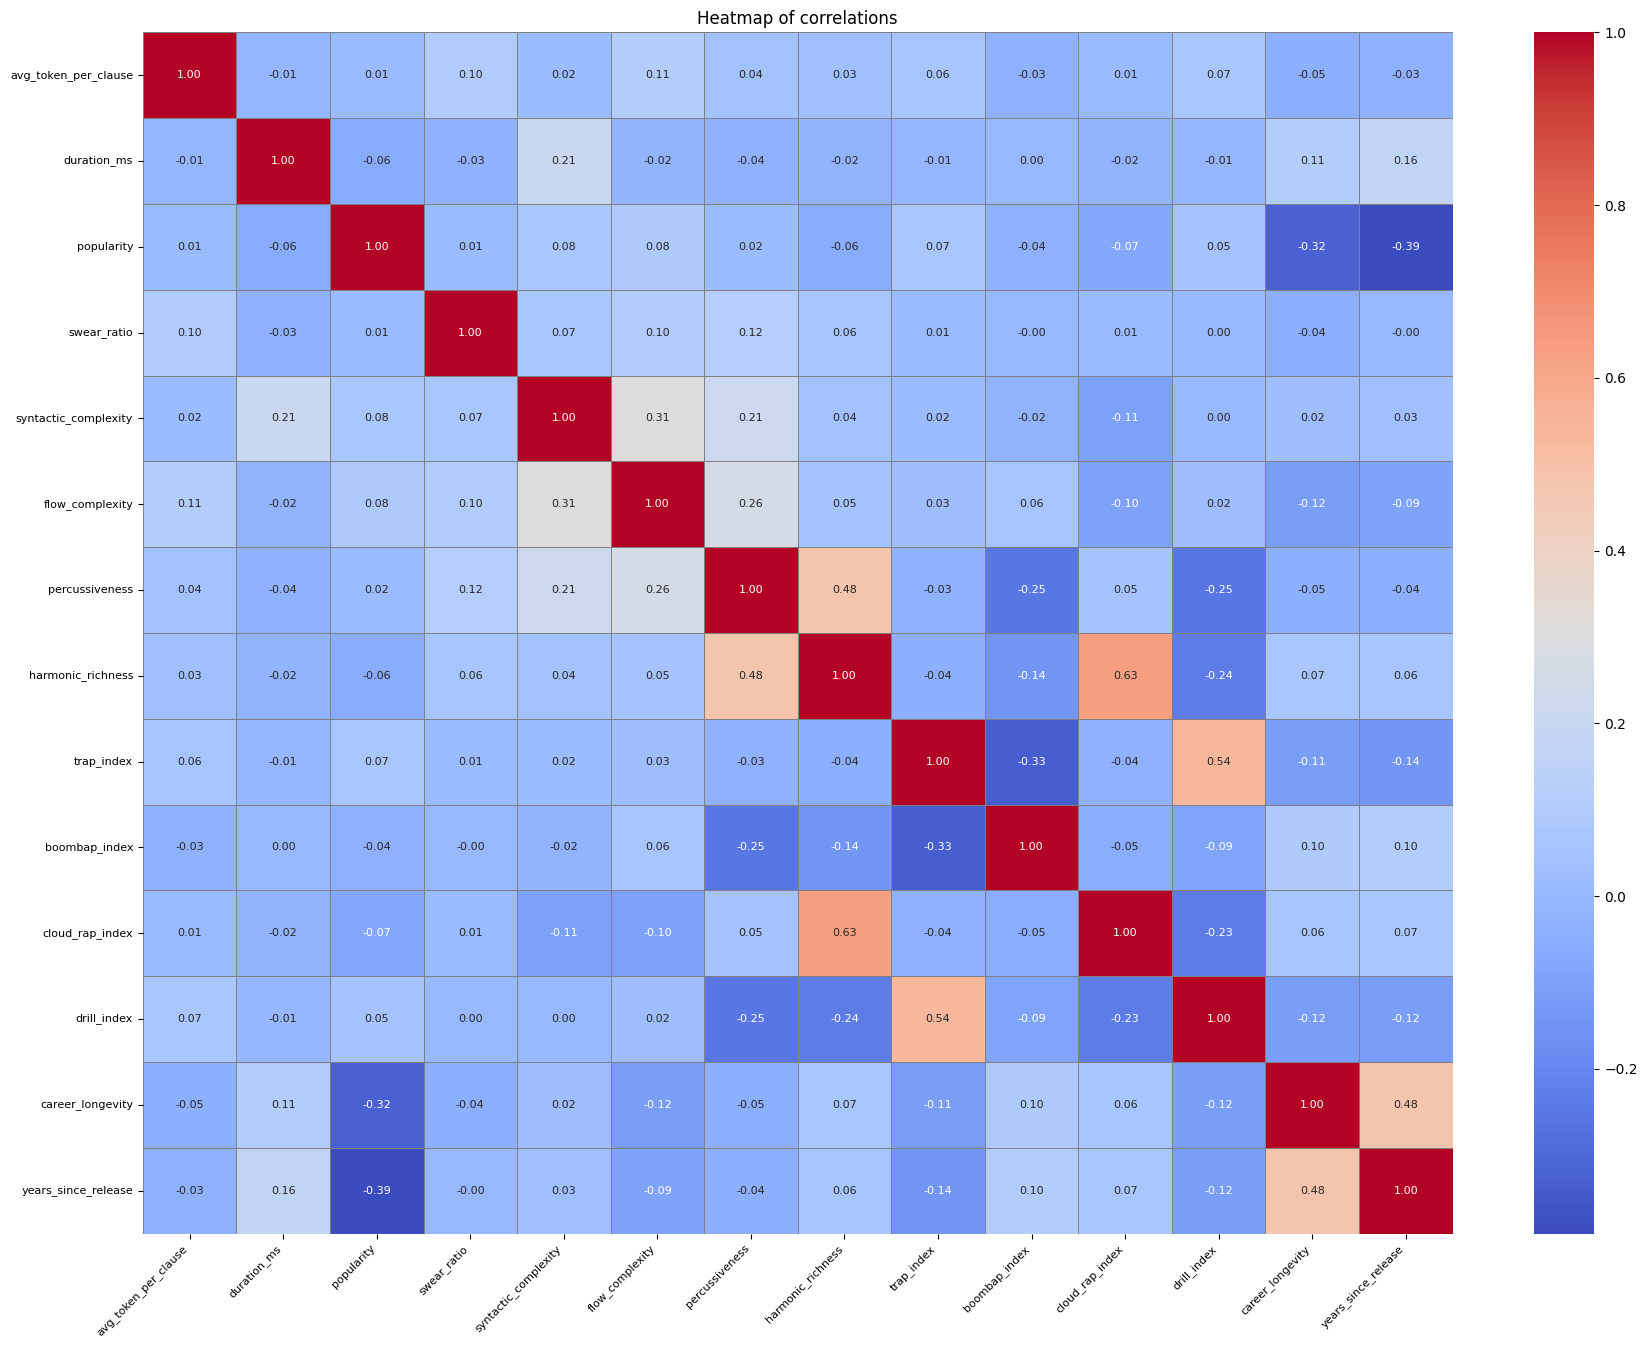

In [15]:
def full_heatmap(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    corr = df[numeric_cols].corr()

    plt.figure(figsize=(18, 14))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, linecolor='gray', annot_kws={"size": 8})
    plt.title("Heatmap of correlations")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()
    return

full_heatmap(df)

## Outliers study

Studying the distribution and acceptable domains of each feature, then performing the outlier removal over all feature except "_popularity_" and "_latitude_", the only ones having an already set domain of definition.

In [16]:

lower_pct = 1
upper_pct = 99

cols = df.columns
cols_no_removal = ["popularity"]


# initialize total outlier mask
outlier_mask_total = pd.Series(False, index=df.index)

for feature in cols:
    col = df[feature]

    min = col.min()
    max = col.max()
    mu = col.mean()
    sigma = col.std()
    median = col.median()

    print("="*40)
    print(f"Feature: {feature}")
    print(f"Min value: {min}")
    print(f"Max value: {max}")
    print(f"Mean value: {mu}")
    print(f"Standard deviation: {sigma}")
    print(f"Median value: {median}")

    if feature in cols_no_removal:
        print(f"Skipping feature (no outlier removal)")
        continue

    # percentile-based thresholds
    lower = col.quantile(lower_pct / 100)
    upper = col.quantile(upper_pct / 100)

    outlier_mask = (col < lower) | (col > upper)
    n_outliers = outlier_mask.sum()

    print(f"Acceptable domain ({lower_pct}-{upper_pct} pct): [{lower:.3f}, {upper:.3f}]")
    print(f"Outliers found: {n_outliers}")

    # accumulate total outlier rows
    outlier_mask_total |= outlier_mask

# Counts total of outliers
print("Outliers rows:", outlier_mask_total.sum())

# Removing outliers rows
df_cleaned = df[~outlier_mask_total]

print("\n")
print(f"Tracks shape after sound outliers removal: {df_cleaned.shape[0]} rows x {df_cleaned.shape[1]} columns")
print("\n")

Feature: avg_token_per_clause
Min value: 0.0
Max value: 78.8
Mean value: 7.382634654907799
Standard deviation: 3.577249173379548
Median value: 6.757575757575758
Acceptable domain (1-99 pct): [3.773, 18.480]
Outliers found: 194
Feature: duration_ms
Min value: 11426.0
Max value: 3753057.0
Mean value: 202147.3543633911
Standard deviation: 88761.76139767445
Median value: 195533.0
Acceptable domain (1-99 pct): [74481.680, 379555.840]
Outliers found: 194
Feature: popularity
Min value: 0
Max value: 97
Mean value: 33.13199128359448
Standard deviation: 19.62526187340587
Median value: 33.0
Skipping feature (no outlier removal)
Feature: swear_ratio
Min value: 0.0
Max value: 0.2
Mean value: 0.005970536713947377
Standard deviation: 0.008909976026635607
Median value: 0.0033167495854063
Acceptable domain (1-99 pct): [0.000, 0.039]
Outliers found: 96
Feature: syntactic_complexity
Min value: 0.0
Max value: 6824.830771117943
Mean value: 1034.2079697806716
Standard deviation: 441.77806268996835
Median va

## After outlier removal

Printing again, for the clean dataset:
- distributions
- boxplots
- correlation matrix

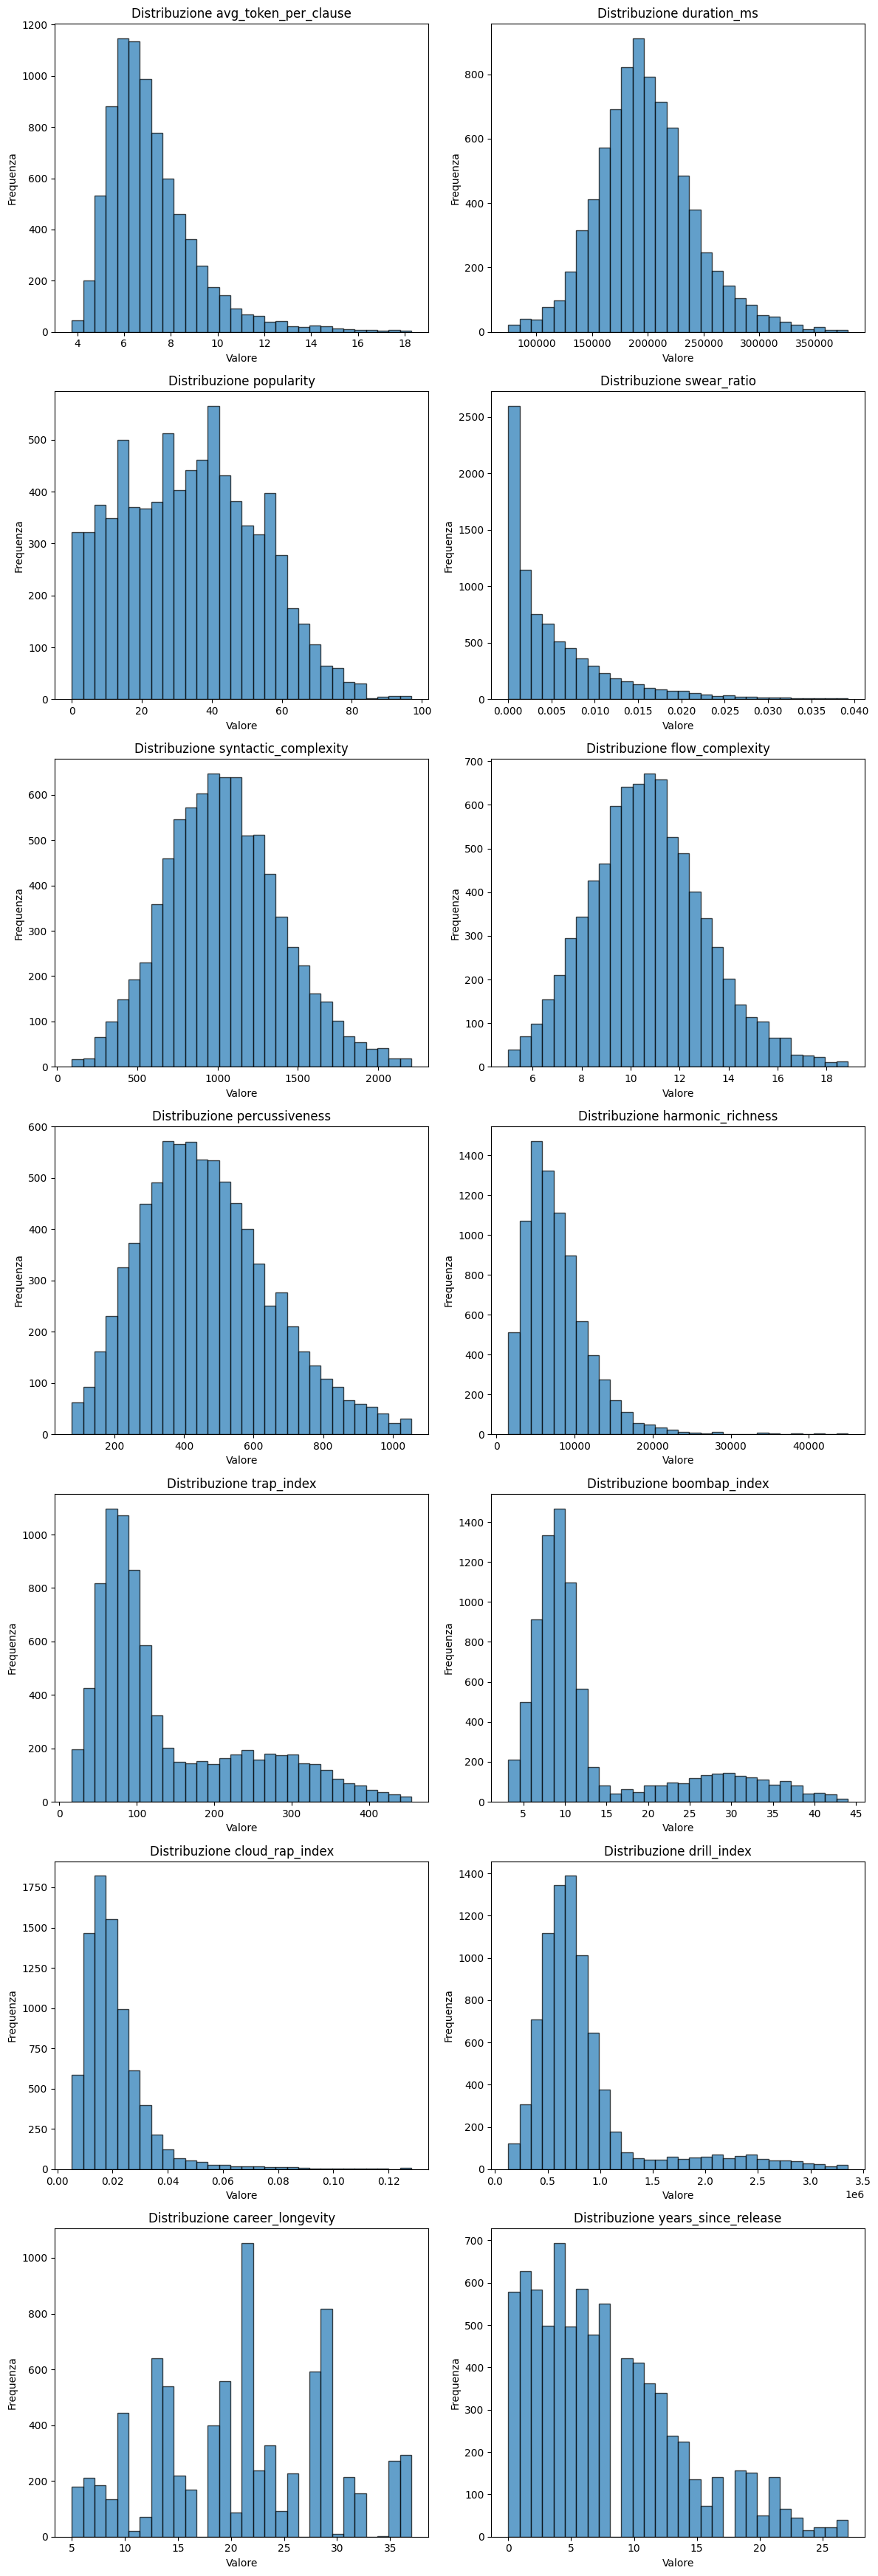

In [17]:
data_distribution(df_cleaned)

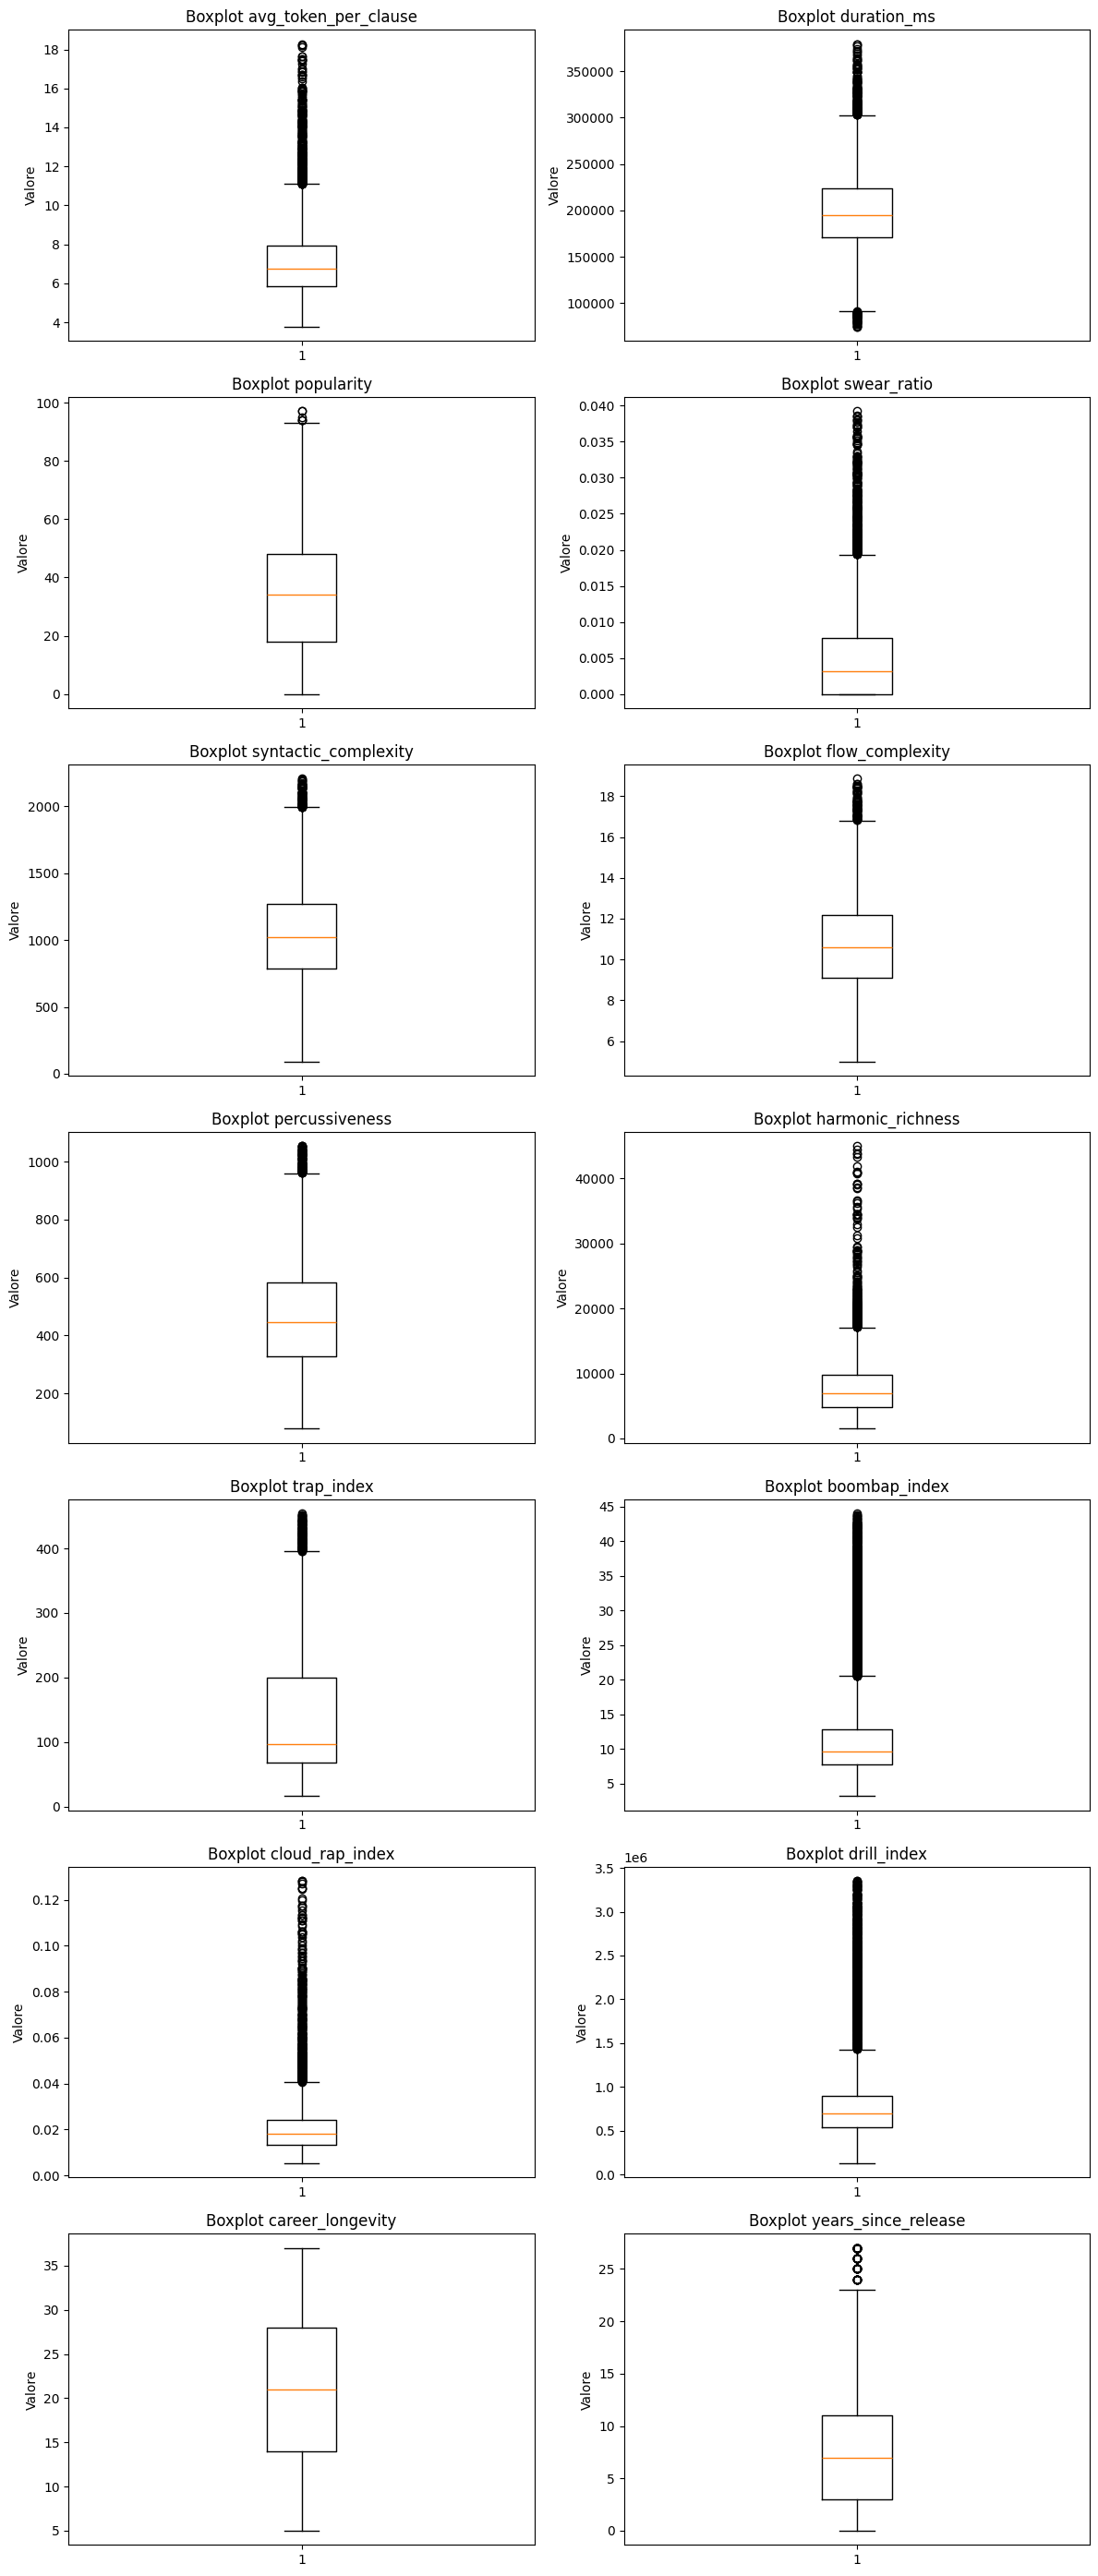

In [18]:
boxplots(df_cleaned)

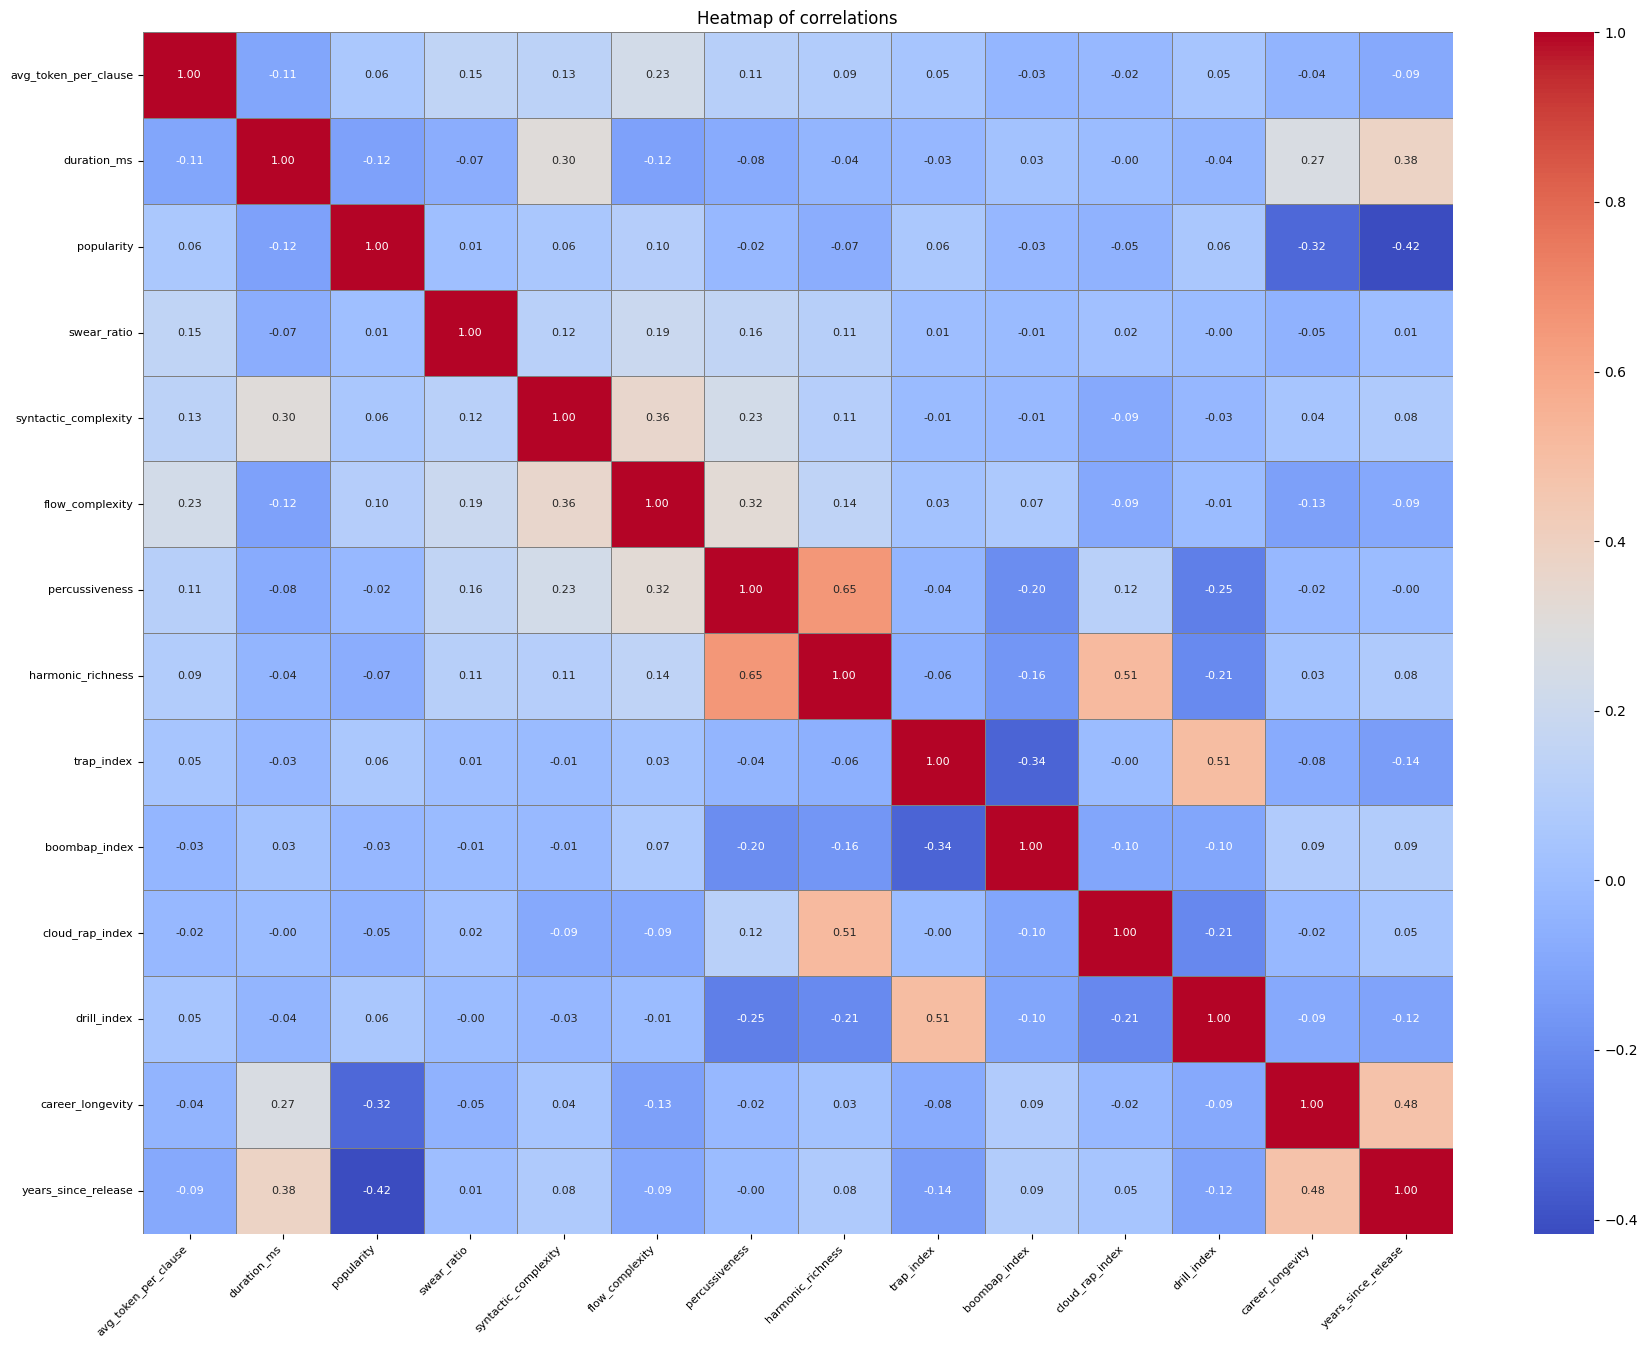

In [19]:
full_heatmap(df_cleaned)

## Saving dataset

In [20]:
df_cleaned.to_csv('../../clustering_dataset/merged_dataset_clean.csv', index=False)